In [1]:
from pathlib import Path

model_folder = Path(f"/mount/NAS-workspace-portal/eeg2025-Vistec/models/ml")
data_folder = Path(f"/mount/NAS-workspace-portal/eeg2025-Vistec/models/data")

In [2]:
# Imports & logging
from pathlib import Path
import numpy as np
import os
from mne import grand_average
import torch
import torch.nn as nn
import torch.nn.functional as F
import sys
sys.path.append(os.path.abspath("/mount/NAS-workspace-portal/eeg2025-Vistec/"))

from eegkit.utils.system.logging_utils import configure_logging, silence_console_logs
from eegkit.models.subject_model import EEGSubjectModel
from eegkit.controller.eeg_controller import EEGController
from eegkit.models.dtos import TaskDTO, SubjectFilterDTO
from eegkit.models.dtos import EvokedParamsDTO
from eegkit.utils.channels import prepare_channels

configure_logging('INFO')
silence_console_logs('WARNING')

### Setup

In [3]:
DATA_DIR = Path(os.getenv("DATA_DIR") or os.getenv("EEG_DATA_DIR") or "")
if not DATA_DIR or not DATA_DIR.exists():
    raise FileNotFoundError("Set DATA_DIR to your BIDS root containing cmi_bids_R*/ directories.")

subject_model = EEGSubjectModel(DATA_DIR)
controller = EEGController(subject_model)

In [4]:
# Parameters: subjects, channels, and evoked window
N_SUBJECTS = 500  # use first N subjects
CHANNELS = "69-76,81-83,88,89"  # explicit posterior channels

# Evoked feature extraction params ([-2, 0] s)
params = EvokedParamsDTO(
    tmin=-2.0,
    tmax=0.0,
    stimulus=[None],
    channels=CHANNELS,
    notch=None,
    uv_min=None,
    uv_max=None,
    clean_flatline_sec=None,
    clean_hf_noise_sd_max=None,
    clean_corr_min=None,
    clean_asr_max_std=None,
    clean_power_min_sd=None,
    clean_power_max_sd=None,
    clean_max_outbound_pct=None,
    clean_window_sec=None,
    spatial_colors=True,
    average_line=True,
)
print(f"Subjects: {N_SUBJECTS}, Channels: {CHANNELS}")

Subjects: 500, Channels: 69-76,81-83,88,89


In [5]:
group_dto = SubjectFilterDTO(task='contrastChangeDetection', subject_limit=N_SUBJECTS)
all_task_dtos = subject_model.get_filter_subjects_dto(group_dto)

seen = set()
selected_dtos = []
for dto in all_task_dtos:
    if dto.subject in seen:
        continue
    seen.add(dto.subject)
    selected_dtos.append(dto)
    if len(selected_dtos) >= N_SUBJECTS:
        break

selected_subjects = [d.subject for d in selected_dtos]
print(f"Selected subjects ({len(selected_subjects)}):", selected_subjects[:10])

Selected subjects (500): ['sub-NDARAA948VFH', 'sub-NDARAB678VYW', 'sub-NDARAB793GL3', 'sub-NDARAC904DMU', 'sub-NDARAD774HAZ', 'sub-NDARAE828CML', 'sub-NDARAG143ARJ', 'sub-NDARAG340ERT', 'sub-NDARAG788YV9', 'sub-NDARAK770XEW']


In [6]:
import ipywidgets as widgets
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Detect available models
def get_available_models(model_folder):
    """Detect all PyTorch model files in the folder."""
    models = []
    if model_folder.exists():
        models = sorted([f.name for f in model_folder.glob("*") if f.is_file()])
    return models

# Detect available data files
def get_available_data(data_folder):
    """Detect Y data files with shape (N, 2) for ACC and RT."""
    data_files = []
    if data_folder.exists():
        for f in sorted(data_folder.glob("Y_*.npy")):
            try:
                data = np.load(f)
                if data.ndim == 2 and data.shape[1] == 2:
                    data_files.append(f.name)
            except Exception:
                pass
    return data_files

def get_available_x_data(data_folder):
    """Detect X data files."""
    x_files = []
    if data_folder.exists():
        x_files = sorted([f.name for f in data_folder.glob("X_*.npy") if f.is_file()])
    return x_files

available_models = get_available_models(model_folder)
available_data = get_available_data(data_folder)
available_x = get_available_x_data(data_folder)

print(f"Found {len(available_models)} models: {available_models}")
print(f"Found {len(available_data)} Y data files: {available_data}")
print(f"Found {len(available_x)} X data files: {available_x}")

Found 2 models: ['evoked_model_500_1771166304.2371216.pkl', 'snr_model_500_1771167871.4968765.pkl']
Found 2 Y data files: ['Y_evoked_500_1771166884.1613965.npy', 'Y_snr_500_1771167865.7485447.npy']
Found 2 X data files: ['X_evoked_500_1771166523.7729328.npy', 'X_snr_500_1771167863.7117176.npy']


In [7]:
selected_x = available_x[0] if available_x else None
x_path = data_folder / selected_x
X = np.load(x_path)

In [8]:
selected_y = available_data[0] if available_data else None
y_path = data_folder / selected_y
y = np.load(y_path)

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# Build groups and keep aligned lengths to avoid indexing errors
groups = np.asarray(selected_subjects)
n = min(len(X), len(y), len(groups))
X = X[:n]
y = y[:n]
groups = groups[:n]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)
print("Unique subjects:", len(np.unique(groups)))

# Subject-wise holdout split (prevents leakage across same subject)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train subjects:", len(np.unique(groups_train)), "Test subjects:", len(np.unique(groups[test_idx])))

X shape: (500, 2613)
y shape: (500, 2)
groups shape: (500,)
Unique subjects: 500
Train shape: (400, 2613) Test shape: (100, 2613)
Train subjects: 400 Test subjects: 100


In [ ]:
def fit_single_target_model(X_tr, y_tr, groups_tr):
    single_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ])

    # Random subspace implemented via max_features
    # max_features controls random feature selection per split (random subspace)
    single_grid = {
        "rf__n_estimators": [50, 100, 200],
        "rf__max_features": [0.3, 0.5, 0.7, 'sqrt', 'log2'],  # Random subspace
        "rf__max_depth": [10, 20, 30, None],
        "rf__min_samples_split": [2, 5, 10],
        "rf__min_samples_leaf": [1, 2, 4],
    }

    single_cv = GroupKFold(n_splits=4)

    search = GridSearchCV(
        estimator=single_pipe,
        param_grid=single_grid,
        scoring="neg_mean_absolute_error",
        cv=single_cv,
        n_jobs=-1,
        refit=True,
        error_score="raise",
    )
    search.fit(X_tr, y_tr, groups=groups_tr)
    return search


# Split into separate targets
y_train_acc = y_train[:, 0]
y_train_rt = y_train[:, 1]

# Train two independent models
acc_search = fit_single_target_model(X_train, y_train_acc, groups_train)
rt_search = fit_single_target_model(X_train, y_train_rt, groups_train)

# Predict on held-out test and combine back to (N, 2)
acc_pred = acc_search.best_estimator_.predict(X_test)
rt_pred = rt_search.best_estimator_.predict(X_test)
y_pred_two = np.column_stack([acc_pred, rt_pred])


def summarize(name, y_true, y_hat):
    """Print ACC/RT correlation and MAE."""
    acc_corr_v = np.corrcoef(y_true[:, 0], y_hat[:, 0])[0, 1]
    rt_corr_v = np.corrcoef(y_true[:, 1], y_hat[:, 1])[0, 1]
    acc_mae_v = mean_absolute_error(y_true[:, 0], y_hat[:, 0])
    rt_mae_v = mean_absolute_error(y_true[:, 1], y_hat[:, 1])

    print(
        f"{name}: "
        f"ACC(corr={acc_corr_v:.4f}, mae={acc_mae_v:.4f}) | "
        f"RT(corr={rt_corr_v:.4f}, mae={rt_mae_v:.4f})"
    )


print("Best params (ACC model):", acc_search.best_params_)
print("Best params (RT model):", rt_search.best_params_)
print()
summarize("Two-model split", y_test, y_pred_two)

# True vs predicted plots for two-model split
plt.figure(figsize=(5, 5))
plt.scatter(y_test[:, 0], y_pred_two[:, 0], alpha=0.7)
acc_lo = min(y_test[:, 0].min(), y_pred_two[:, 0].min())
acc_hi = max(y_test[:, 0].max(), y_pred_two[:, 0].max())
plt.plot([acc_lo, acc_hi], [acc_lo, acc_hi])
plt.xlabel("True ACC (test)")
plt.ylabel("Predicted ACC (two-model)")
plt.title("Random Forest (Random Subspace): True vs Predicted ACC")
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(y_test[:, 1], y_pred_two[:, 1], alpha=0.7)
rt_lo = min(y_test[:, 1].min(), y_pred_two[:, 1].min())
rt_hi = max(y_test[:, 1].max(), y_pred_two[:, 1].max())
plt.plot([rt_lo, rt_hi], [rt_lo, rt_hi])
plt.xlabel("True RT (test)")
plt.ylabel("Predicted RT (two-model)")
plt.title("Random Forest (Random Subspace): True vs Predicted RT")
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt


def evaluate_model(y_true, y_pred, target_name):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1]

    # Baseline (mean predictor)
    baseline_pred = np.full_like(y_true, y_true.mean())
    baseline_mae = mean_absolute_error(y_true, baseline_pred)

    print(f"\n===== {target_name} =====")
    print(f"MAE        : {mae:.4f}")
    print(f"Baseline MAE: {baseline_mae:.4f}")
    print(f"R2         : {r2:.4f}")
    print(f"Correlation: {corr:.4f}")

    return mae, r2, corr, baseline_mae


# True values
y_test_acc = y_test[:, 0]
y_test_rt = y_test[:, 1]

# Evaluate
acc_results = evaluate_model(y_test_acc, acc_pred, "ACC")
rt_results  = evaluate_model(y_test_rt, rt_pred, "RT")



===== ACC =====
MAE        : 16.7990
Baseline MAE: 16.6948
R2         : 0.0074
Correlation: 0.1088

===== RT =====
MAE        : 0.1832
Baseline MAE: 0.1845
R2         : -0.0102
Correlation: -0.1206


In [ ]:
print("\nBest ACC params:", acc_search.best_params_)
print("Best RT params :", rt_search.best_params_)
print("\nACC CV best score:", acc_search.best_score_)
print("RT CV best score :", rt_search.best_score_)


Best ACC params: {'pca__n_components': 0.95, 'ridge__alpha': np.float64(1000.0)}
Best RT params : {'pca__n_components': 0.9, 'ridge__alpha': np.float64(1000.0)}

ACC CV best score: -17.593492898512267
RT CV best score : -0.17463313386842266


In [ ]:
import pandas as pd

summary = pd.DataFrame({
    "Target": ["ACC", "RT"],
    "MAE": [acc_results[0], rt_results[0]],
    "Baseline_MAE": [acc_results[3], rt_results[3]],
    "R2": [acc_results[1], rt_results[1]],
    "Correlation": [acc_results[2], rt_results[2]],
})

print("\nPerformance Summary:")
print(summary)



Performance Summary:
  Target        MAE  Baseline_MAE        R2  Correlation
0    ACC  16.799043     16.694813  0.007370     0.108817
1     RT   0.183221      0.184532 -0.010178    -0.120627


In [1]:
from pathlib import Path
import joblib
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupShuffleSplit

model_dir = Path('/mount/NAS-workspace-portal/eeg2025-Vistec/models/ml')
model_files = sorted(model_dir.glob('random_forest_subspace_*.pkl'), key=lambda p: p.stat().st_mtime)
if not model_files:
    raise FileNotFoundError(f'No model found in {model_dir} matching random_forest_subspace_*.pkl')

latest_model = model_files[-1]
artifact = joblib.load(latest_model)

print('Loaded model:', latest_model)
print('Saved training metrics:', artifact.get('metrics', {}))
print('Best ACC params:', artifact.get('acc_best_params', {}))
print('Best RT params :', artifact.get('rt_best_params', {}))

x_file = Path(artifact['x_file'])
y_file = Path(artifact['y_file'])
X_eval = np.load(x_file)
y_eval = np.load(y_file)
n_subjects = int(artifact.get('n_subjects', len(X_eval)))

n = min(len(X_eval), len(y_eval), n_subjects)
X_eval = X_eval[:n]
y_eval = y_eval[:n]
groups_eval = np.arange(n)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
_, test_idx_eval = next(gss.split(X_eval, y_eval, groups=groups_eval))
X_test_eval = X_eval[test_idx_eval]
y_test_eval = y_eval[test_idx_eval]

acc_model = artifact['acc_model']
rt_model = artifact['rt_model']
acc_pred_eval = acc_model.predict(X_test_eval)
rt_pred_eval = rt_model.predict(X_test_eval)

def eval_target(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    print(f'===== {name} =====')
    print(f'MAE        : {mae:.4f}')
    print(f'R2         : {r2:.4f}')
    print(f'Correlation: {corr:.4f}')

print('\nRe-evaluation on reproduced test split:')
eval_target(y_test_eval[:, 0], acc_pred_eval, 'ACC')
eval_target(y_test_eval[:, 1], rt_pred_eval, 'RT')

Loaded model: /mount/NAS-workspace-portal/eeg2025-Vistec/models/ml/random_forest_subspace_500_1771499598.pkl
Saved training metrics: {'acc_corr': 0.20532453613153853, 'rt_corr': -0.010301592165428745, 'acc_mae': 17.150281249773297, 'rt_mae': 0.18598154051011273}
Best ACC params: {'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Best RT params : {'rf__max_depth': 10, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}

Re-evaluation on reproduced test split:
===== ACC =====
MAE        : 17.1503
R2         : 0.0155
Correlation: 0.2053
===== RT =====
MAE        : 0.1860
R2         : -0.0286
Correlation: -0.0103


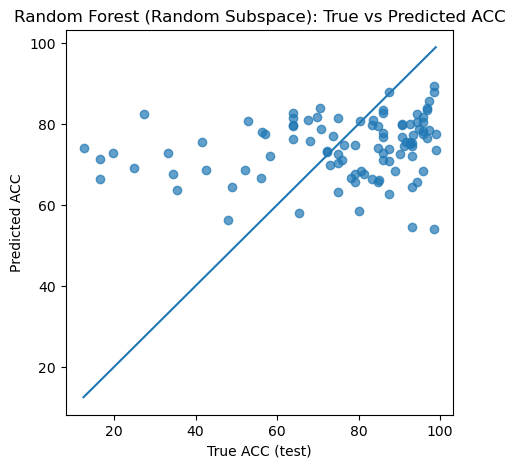

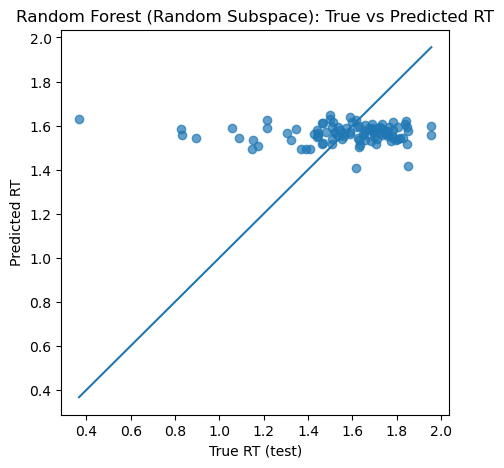

In [5]:
import matplotlib.pyplot as plt

# True vs Predicted: ACC
plt.figure(figsize=(5, 5))
plt.scatter(y_test_eval[:, 0], acc_pred_eval, alpha=0.7)
acc_lo = min(y_test_eval[:, 0].min(), acc_pred_eval.min())
acc_hi = max(y_test_eval[:, 0].max(), acc_pred_eval.max())
plt.plot([acc_lo, acc_hi], [acc_lo, acc_hi])
plt.xlabel('True ACC (test)')
plt.ylabel('Predicted ACC')
plt.title('Random Forest (Random Subspace): True vs Predicted ACC')
plt.show()

# True vs Predicted: RT
plt.figure(figsize=(5, 5))
plt.scatter(y_test_eval[:, 1], rt_pred_eval, alpha=0.7)
rt_lo = min(y_test_eval[:, 1].min(), rt_pred_eval.min())
rt_hi = max(y_test_eval[:, 1].max(), rt_pred_eval.max())
plt.plot([rt_lo, rt_hi], [rt_lo, rt_hi])
plt.xlabel('True RT (test)')
plt.ylabel('Predicted RT')
plt.title('Random Forest (Random Subspace): True vs Predicted RT')
plt.show()